In [13]:

import math
from collections.abc import Sequence
from functools import lru_cache
from io import StringIO
from itertools import product

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import PercentFormatter

from 中间结果.不同购买策略的比较 import 不同购买策略的比较
from 信用交易所模型 import 信用交易所, 信用交易所商品

plt.rcParams['font.family'] = "serif"
plt.rcParams['font.serif'] = ["CMU Serif", "Source Han Serif SC"]
plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams["axes.titleweight"] = "bold"

In [15]:
data_str = """主线进度0关卡数量	控制中枢等级	高阶商品占分等阶商品
159	5	89.15%
48	3	28.49%
149	5	87.86%
95	5	87.06%
84	5	89.53%
159	5	90.88%
159	5	89.68%
81	5	88.84%
99	5	90.77%
98	5	87.95%
92	5	89.32%
106	5	89.48%
78	5	86.35%
156	3	89.40%
95	5	85.35%
91	5	89.17%
159	5	89.47%
78	5	88.72%
159	5	89.59%
96	5	89.30%
159	5	87.83%
64	4	55.92%
64	3	50.34%
74	3	91.52%
71	2	89.09%
76	4	88.45%
58	3	47.03%
82	4	89.14%
156	1	89.06%
78	5	89.20%
79	4	88.35%
159	5	91.39%
79	5	89.60%
68	4	88.23%
159	5	87.17%
78	4	89.17%
159	5	88.02%
158	5	91.44%
159	5	87.36%
159	5	85.68%
84	5	89.09%
159	5	85.33%
159	5	86.27%
19	1	0.00%
74	4	88.03%
33	3	18.58%
33	2	16.09%
19	1	0.00%
80	4	86.76%
59	1	45.74%
52	2	26.80%
33	3	17.98%
22	1	0.00%
23	1	0.00%
25	1	0.00%
27	1	14.52%
30	1	17.00%
28	1	22.07%
31	1	18.64%
37	2	17.23%
41	2	25.93%
53	2	37.34%
55	2	35.01%
58	2	46.31%
54	2	36.22%
66	1	52.94%
65	1	55.25%
67	1	68.01%
159	5	87.77%
159	5	88.20%
89	5	87.72%
91	5	89.84%
135	5	90.26%
151	5	87.50%
81	4	88.62%
85	5	89.95%
159	5	86.13%
108	5	87.57%
95	5	86.30%
159	5	86.90%"""

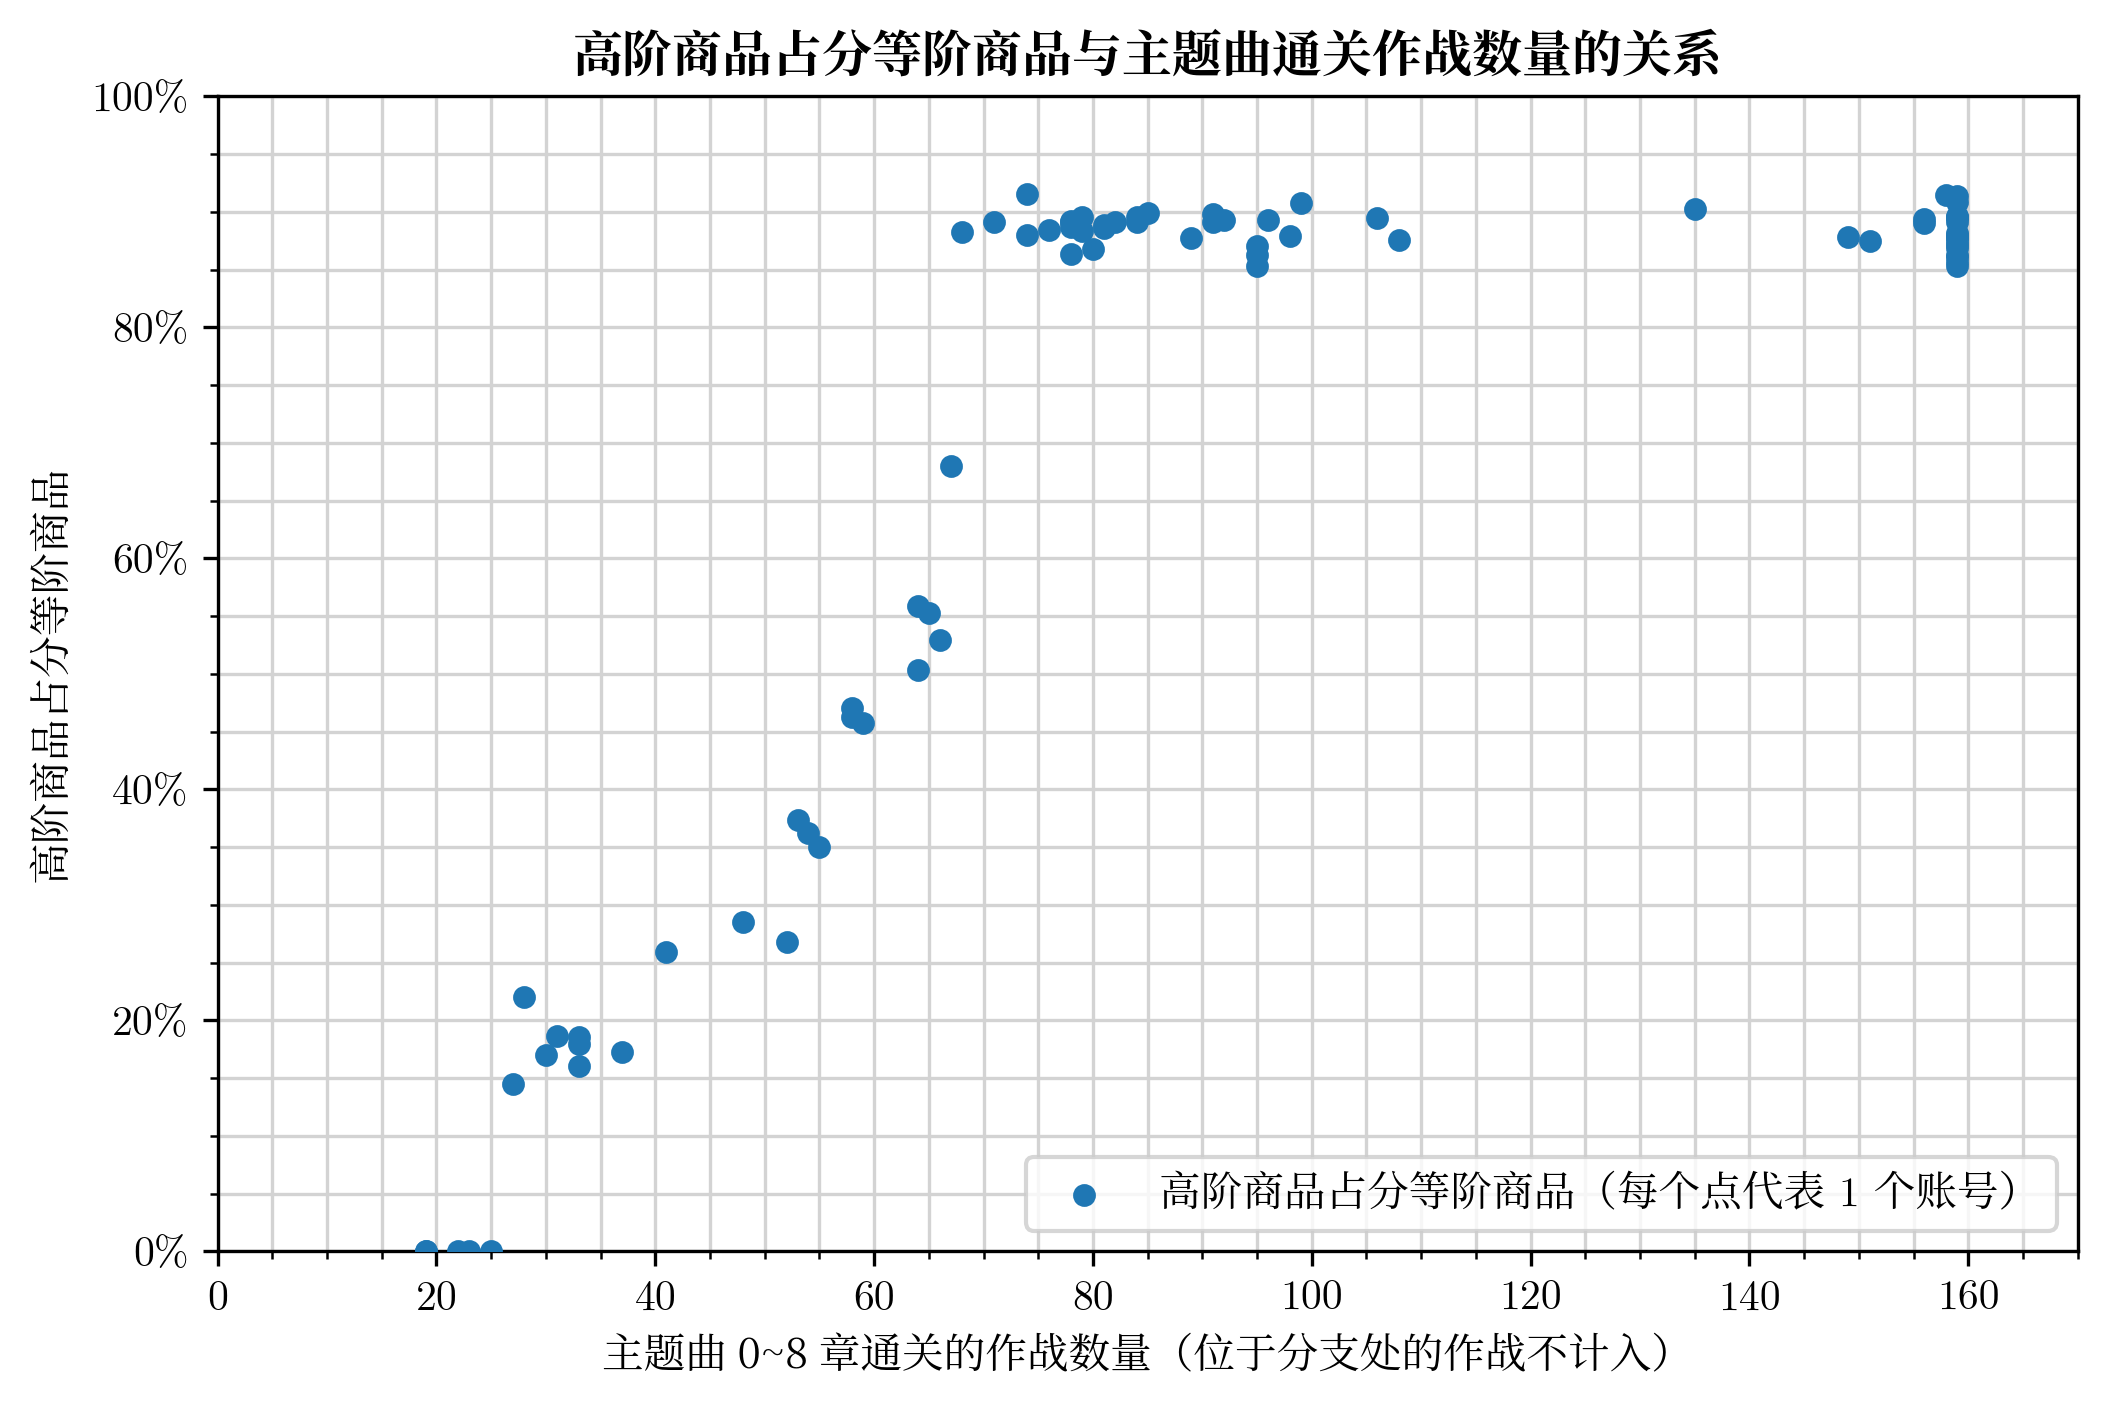

In [23]:
data = pd.read_csv(StringIO(data_str), sep="\t")
# 将“高阶商品占分等阶商品”列去掉百分号并转为浮点数
data["高阶商品占分等阶商品"] = data["高阶商品占分等阶商品"].str.rstrip("%").astype(float) / 100

plt.figure(figsize=(8, 5))
plt.scatter(data["主线进度0关卡数量"], data["高阶商品占分等阶商品"], s=20, label="高阶商品占分等阶商品（每个点代表 1 个账号）", zorder=100)
plt.xlabel("主题曲 0~8 章通关的作战数量（位于分支处的作战不计入）", family=["Source Han Serif SC"])
plt.ylabel("高阶商品占分等阶商品", family=["Source Han Serif SC"])
plt.xlim(0, 170)
plt.ylim(0, 1)
plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))
plt.title("高阶商品占分等阶商品与主题曲通关作战数量的关系", family=["Source Han Serif SC"])
plt.legend(loc="lower right", prop={"family": ["CMU Serif", "Source Han Serif SC"]})
plt.minorticks_on()
plt.grid(color='lightgray', which='both')
plt.savefig("figures/高阶商品占分等阶商品与主题曲通关作战数量的关系.png", bbox_inches='tight')

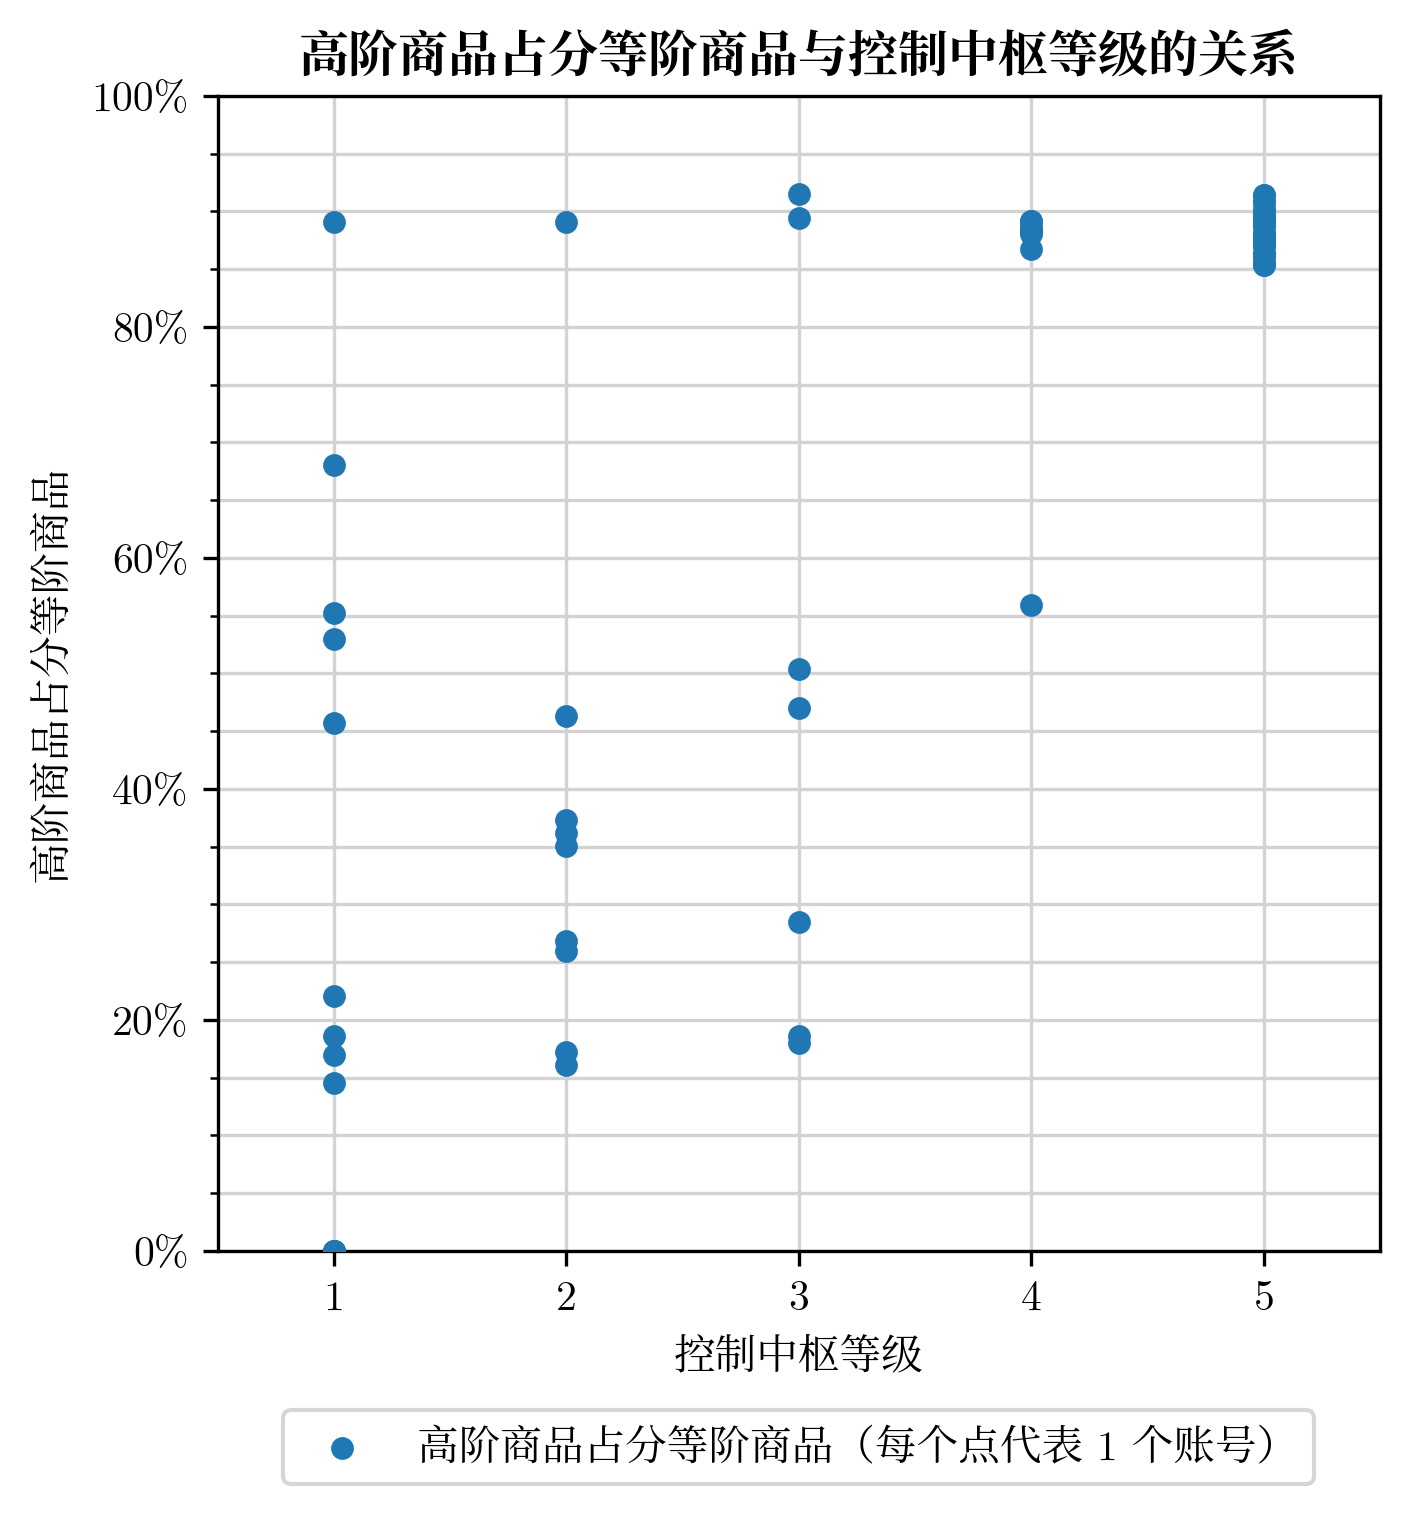

In [24]:
data = pd.read_csv(StringIO(data_str), sep="\t")
# 将“高阶商品占分等阶商品”列去掉百分号并转为浮点数
data["高阶商品占分等阶商品"] = data["高阶商品占分等阶商品"].str.rstrip("%").astype(float) / 100

plt.figure(figsize=(5, 5))
plt.scatter(data["控制中枢等级"], data["高阶商品占分等阶商品"], s=20, label="高阶商品占分等阶商品（每个点代表 1 个账号）", zorder=100)
plt.xlabel("控制中枢等级", family=["Source Han Serif SC"])
plt.ylabel("高阶商品占分等阶商品", family=["Source Han Serif SC"])
plt.xlim(0.5, 5.5)
plt.ylim(0, 1)
plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))
plt.title("高阶商品占分等阶商品与控制中枢等级的关系", family=["Source Han Serif SC"])
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=1, prop={"family": ["CMU Serif", "Source Han Serif SC"]})
plt.gca().yaxis.minorticks_on()
plt.grid(color='lightgray', which='both')
plt.savefig("figures/高阶商品占分等阶商品与控制中枢等级的关系.png", bbox_inches='tight')

In [6]:
最优购买策略 = 不同购买策略的比较["考虑天数为 N = 11 时的信用交易所最优购买策略"]
从左到右购买策略 = 不同购买策略的比较["从左到右购买，直到不能购买为止策略"]
按性价比从高到低购买策略 = 不同购买策略的比较["按性价比从高到低购买，直到不能购买为止策略"]
性价比加阈值策略 = 不同购买策略的比较["按性价比从高到低购买，并设定性价比阈值策略"]
每日多获得的129信用的价值 = 最优购买策略(942) - 最优购买策略(813)
从左到右购买策略的表现 = 从左到右购买策略(813) / 最优购买策略(813)
按性价比从高到低购买策略的表现 = 按性价比从高到低购买策略(813) / 最优购买策略(813)
性价比加阈值策略的表现 = 性价比加阈值策略(813) / 最优购买策略(813)
print(f"3 发电站基建布局比 2 发电站基建布局每日多获得的 129 信用大约相当于 {每日多获得的129信用的价值:.4f} 理智。")
print(f"“从左到右购买，直到不能购买为止”策略的表现只有最优策略的 {从左到右购买策略的表现:.4%} 左右。")
print(f"“按性价比从高到低购买，直到不能购买为止”策略的表现可以达到最优策略的 {按性价比从高到低购买策略的表现:.4%} 左右。")
print(f"“按性价比从高到低购买，并设定性价比阈值”策略的表现可以进一步达到最优策略的 {性价比加阈值策略的表现:.4%} 左右。")

3 发电站基建布局比 2 发电站基建布局每日多获得的 129 信用大约相当于 5.3271 理智。
“从左到右购买，直到不能购买为止”策略的表现只有最优策略的 86.1272% 左右。
“按性价比从高到低购买，直到不能购买为止”策略的表现可以达到最优策略的 98.6573% 左右。
“按性价比从高到低购买，并设定性价比阈值”策略的表现可以进一步达到最优策略的 99.9555% 左右。


## 最优策略不稳定的例子

In [ ]:
# 最优策略不稳定的例子

@lru_cache(maxsize=None)
def 计算总价格(购买指标向量: Sequence[bool]) -> int:
    return sum(商品.现价 for i, 商品 in enumerate(商店.商品列表) if 购买指标向量[i])


@lru_cache(maxsize=None)
def 计算总价值(购买指标向量: Sequence[bool]) -> float:
    return sum(商品.价值 for i, 商品 in enumerate(商店.商品列表) if 购买指标向量[i])


def 求解单个商店最优购买策略(当前信用: int, K_n_C_x: list[float]) -> tuple[float, tuple[bool, ...]]:
    """在 2**10 种购买方案中选一种不超支的，使得 当天购买的物品总价值 + K_n_C_x[能够继承的信用] 最大"""
    目标函数最大值: float = -math.inf
    最优策略购买指标向量: tuple[bool, ...] = tuple(False for _ in range(len(商店.商品列表)))
    for 购买指标向量 in product((False, True), repeat=len(商店.商品列表)):  # 枚举 2 ** 10 种购买方案
        总价格: int = 计算总价格(购买指标向量)
        总价值: float = 计算总价值(购买指标向量)
        if 总价格 <= 当前信用:
            剩余信用: int = 当前信用 - 总价格
            能够继承的信用: int = min(剩余信用, 300)
            目标函数: float = 总价值 + K_n_C_x[能够继承的信用]
            if 目标函数 > 目标函数最大值:
                目标函数最大值 = 目标函数
                最优策略购买指标向量 = 购买指标向量

    return 目标函数最大值, 最优策略购买指标向量


def 标准化(K_n_C_x: list[float]) -> list[float]:
    """将 K_n_C_x 标准化到 [0, 1]"""
    return [K_n_C_x[c] - K_n_C_x[0] for c in range(301)]


# 模拟购买的商店
# 商店 = 信用交易所(剩余信用=0, 商品列表=[
#     信用交易所商品(商品名称="破损装置×2", 折扣=75, 已购买=False),
#     信用交易所商品(商品名称="赤金×6", 折扣=75, 已购买=False),
#     信用交易所商品(商品名称="糖×2", 折扣=50, 已购买=False),
#     信用交易所商品(商品名称="源岩×2", 折扣=50, 已购买=False),
#     信用交易所商品(商品名称="酮凝集×2", 折扣=50, 已购买=False),
#     信用交易所商品(商品名称="糖×2", 折扣=0, 已购买=False),
#     信用交易所商品(商品名称="龙门币×3600", 折扣=0, 已购买=False),
#     信用交易所商品(商品名称="初级作战记录×9", 折扣=0, 已购买=False),
#     信用交易所商品(商品名称="初级作战记录×9", 折扣=0, 已购买=False),
#     信用交易所商品(商品名称="招聘许可×1", 折扣=0, 已购买=False),
# ])


# 不稳定的商店
商店 = 信用交易所(剩余信用=0, 商品列表=[
    信用交易所商品(商品名称="糖×2", 折扣=75, 已购买=False),
    信用交易所商品(商品名称="酮凝集×2", 折扣=50, 已购买=False),
    信用交易所商品(商品名称="糖×2", 折扣=50, 已购买=False),
    信用交易所商品(商品名称="碳素×3", 折扣=50, 已购买=False),
    信用交易所商品(商品名称="基础作战记录×9", 折扣=50, 已购买=False),
    信用交易所商品(商品名称="家具零件×25", 折扣=50, 已购买=False),
    信用交易所商品(商品名称="招聘许可×1", 折扣=50, 已购买=False),
    信用交易所商品(商品名称="招聘许可×1", 折扣=0, 已购买=False),
    信用交易所商品(商品名称="家具零件×20", 折扣=0, 已购买=False),
    信用交易所商品(商品名称="装置×1", 折扣=0, 已购买=False),
])


每日获得的信用C = 813
考虑的天数N = 41

K_0_C_x: list[float] = [0 for _ in range(301)]
K_x_C_x: list[list[float]] = [K_0_C_x]

for n in range(1, 考虑的天数N):
    K_n减1_C_x: list[float] = K_x_C_x[-1]
    K_n_C_x: list[float] = [0 for _ in range(301)]
    for 继承的信用c in range(301):
        目标函数最大值, _ = 求解单个商店最优购买策略(继承的信用c + 每日获得的信用C, K_n减1_C_x)
        K_n_C_x[继承的信用c] = 目标函数最大值
        # print(f'K_{n}_{每日获得的信用C}_{继承的信用c} = {K_n_C_x[继承的信用c]}')
    K_x_C_x.append(K_n_C_x)

# for n, K_n_C_x in enumerate(K_x_C_x):
#     print(f'K_{n}_{每日获得的信用C}_x: {K_n_C_x}')

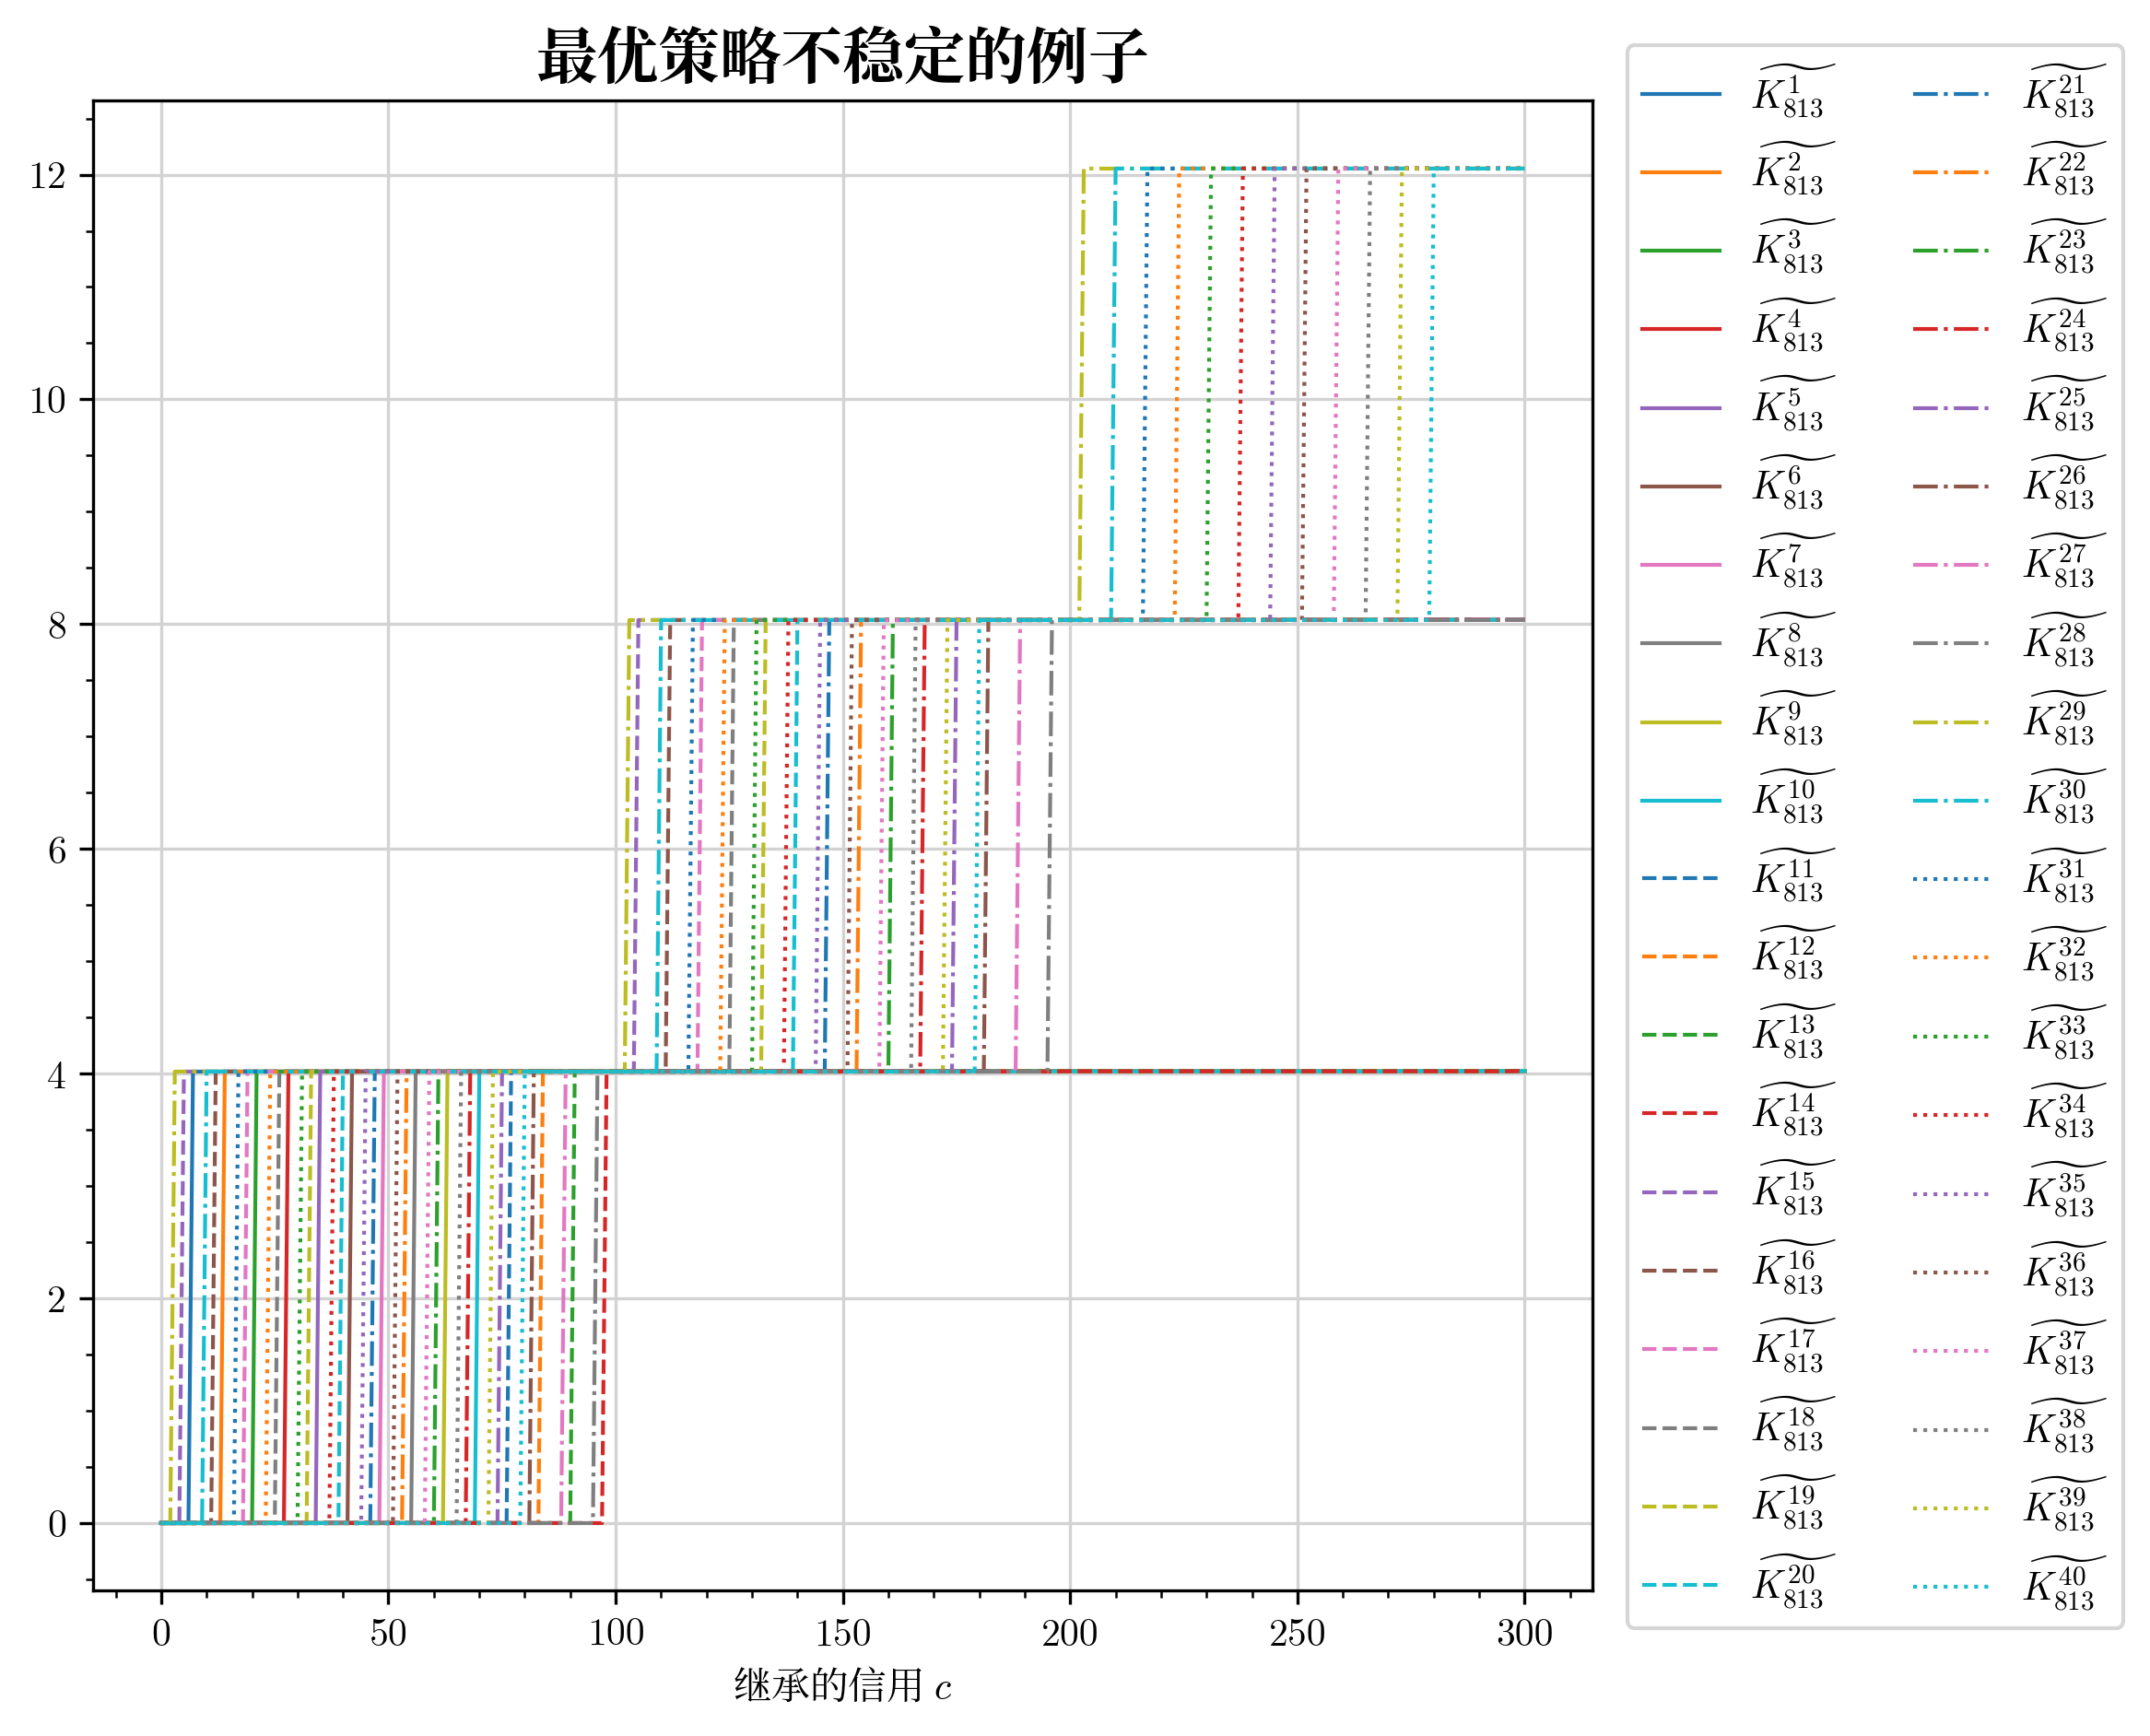

In [26]:
plt.figure(figsize=(7, 7))
for n, K_n_C_x in enumerate(K_x_C_x):
    if n == 0:
        continue
    标准化的K_n_C_x = 标准化(K_n_C_x)
    if 0 < n <= 10:
        linestyle = '-'
    elif 10 < n <= 20:
        linestyle = '--'
    elif 20 < n <= 30:
        linestyle = '-.'
    else:
        linestyle = ':'
    plt.plot(range(301), 标准化的K_n_C_x, linestyle=linestyle, linewidth=1, label=r'$\widetilde{K^{%d}_{813}}$' % n)
plt.title("最优策略不稳定的例子", fontsize=16, family=["Source Han Serif SC"])
plt.xlabel("继承的信用 $c$", family=["Source Han Serif SC"])
plt.legend(ncol=2, bbox_to_anchor=(1.01, 1.05), loc='upper left')
plt.minorticks_on()
plt.grid(color='lightgray', which='major')
plt.savefig("figures/最优策略不稳定的例子.png", bbox_inches='tight')

In [9]:
from 中间结果.信用能购买的商品碎片的价值 import 信用能购买的商品碎片的价值的导数

print(信用能购买的商品碎片的价值的导数(813), 信用能购买的商品碎片的价值的导数(942))

0.044106071676786485 0.032069391600373365


In [ ]:
from 信用交易所商品信息 import 信用交易所商品名称列表, 信用交易所商品价格字典, 信用交易所商品理智价值字典

for 商品名称 in 信用交易所商品名称列表:
    价格 = 信用交易所商品价格字典[商品名称]
    价值 = 信用交易所商品理智价值字典[商品名称]
    原价性价比 = 价值 / 价格
    print(f"{商品名称}\t{原价性价比:.4f}\t{原价性价比*2:.4f}\t{原价性价比*4:.4f}\t{原价性价比*20:.4f}\t{原价性价比*100:.4f}")

龙门币×1800	0.0648	0.1296	0.2592	1.2960	6.4800
龙门币×3600	0.0648	0.1296	0.2592	1.2960	6.4800
家具零件×20	0.0000	0.0000	0.0001	0.0003	0.0013
家具零件×25	0.0000	0.0000	0.0001	0.0003	0.0013
招聘许可×1	0.1772	0.3544	0.7087	3.5437	17.7187
加急许可×1	0.0000	0.0000	0.0000	0.0001	0.0006
赤金×6	0.0342	0.0684	0.1368	0.6838	3.4192
基础作战记录×9	0.0410	0.0821	0.1641	0.8206	4.1031
初级作战记录×9	0.0410	0.0821	0.1641	0.8206	4.1031
技巧概要·卷1×5	0.0492	0.0984	0.1967	0.9835	4.9175
技巧概要·卷2×3	0.0600	0.1200	0.2400	1.2002	6.0010
碳×5	0.0267	0.0534	0.1069	0.5344	2.6718
碳素×3	0.0201	0.0402	0.0804	0.4018	2.0090
源岩×2	0.0297	0.0594	0.1189	0.5944	2.9720
代糖×2	0.0383	0.0765	0.1531	0.7654	3.8272
酯原料×2	0.0381	0.0762	0.1524	0.7618	3.8090
异铁碎片×2	0.0384	0.0767	0.1534	0.7670	3.8351
双酮×2	0.0391	0.0782	0.1564	0.7822	3.9109
破损装置×2	0.0393	0.0786	0.1572	0.7859	3.9297
固源岩×3	0.0530	0.1060	0.2120	1.0602	5.3011
糖×2	0.0571	0.1142	0.2283	1.1417	5.7084
聚酸酯×2	0.0568	0.1136	0.2272	1.1362	5.6812
异铁×2	0.0573	0.1145	0.2290	1.1451	5.7257
酮凝集×2	0.0584	0.1168	0.2336	1.1679	5.83

In [11]:
from 信用交易所商品信息 import 信用交易所商品名称列表, 信用交易所商品价格字典, 信用交易所商品理智价值字典, 物品名称到价值的映射字典
import math

for 商品名称 in 信用交易所商品名称列表:
    物品名称, 数量 = 商品名称.split("×")
    数量 = int(数量)
    原价 = 信用交易所商品价格字典[商品名称]
    单件物品价值 = 物品名称到价值的映射字典[物品名称]
    整组商品价值 = 信用交易所商品理智价值字典[商品名称]
    assert math.isclose(单件物品价值 * 数量, 整组商品价值, rel_tol=1e-5)
    原价性价比 = 整组商品价值 / 原价
    print(f"{商品名称}\t{物品名称}\t{数量}\t{原价}\t{单件物品价值:.4f}\t{整组商品价值:.4f}\t{原价性价比:.4f}")

龙门币×1800	龙门币	1800	100	0.0036	6.4800	0.0648
龙门币×3600	龙门币	3600	200	0.0036	12.9600	0.0648
家具零件×20	家具零件	20	160	0.0001	0.0020	0.0000
家具零件×25	家具零件	25	200	0.0001	0.0025	0.0000
招聘许可×1	招聘许可	1	160	28.3499	28.3499	0.1772
加急许可×1	加急许可	1	160	0.0010	0.0010	0.0000
赤金×6	赤金	6	160	0.9118	5.4707	0.0342
基础作战记录×9	基础作战记录	9	100	0.4559	4.1031	0.0410
初级作战记录×9	初级作战记录	9	200	0.9118	8.2061	0.0410
技巧概要·卷1×5	技巧概要·卷1	5	160	1.5736	7.8680	0.0492
技巧概要·卷2×3	技巧概要·卷2	3	200	4.0007	12.0021	0.0600
碳×5	碳	5	160	0.8550	4.2749	0.0267
碳素×3	碳素	3	200	1.3393	4.0180	0.0201
源岩×2	源岩	2	80	1.1888	2.3776	0.0297
代糖×2	代糖	2	100	1.9136	3.8272	0.0383
酯原料×2	酯原料	2	100	1.9045	3.8090	0.0381
异铁碎片×2	异铁碎片	2	120	2.3010	4.6021	0.0384
双酮×2	双酮	2	120	2.3465	4.6930	0.0391
破损装置×2	破损装置	2	160	3.1438	6.2876	0.0393
固源岩×3	固源岩	3	200	3.5341	10.6022	0.0530
糖×2	糖	2	200	5.7084	11.4169	0.0571
聚酸酯×2	聚酸酯	2	200	5.6812	11.3623	0.0568
异铁×2	异铁	2	240	6.8708	13.7416	0.0573
酮凝集×2	酮凝集	2	240	7.0072	14.0145	0.0584
装置×1	装置	1	160	9.3991	9.3991	0.0587


In [11]:
import random

from 信用交易所模型 import 信用交易所
from 信用交易所购买策略 import 从左到右购买_设定黑白名单策略, 模拟一轮购买, 按性价比从高到低购买_并设定性价比阈值策略
from 统计结果 import 信用交易所统计结果

每日获得的信用列表 = range(0, 1001, 4)
初始继承信用 = 0

random.seed(0)
顺序: list[int] = list(range(len(信用交易所统计结果))) * 10
random.shuffle(顺序)
商店列表: list[信用交易所] = [信用交易所统计结果[商店序号].设为全部未购买() for 商店序号 in 顺序]

策略FF = 从左到右购买_设定黑白名单策略(
    黑名单=['加急许可×1', '家具零件×20', '家具零件×25', '碳×5', '碳素×3'],
    白名单=['招聘许可×1', '龙门币×1800', '龙门币×3600', '技巧概要·卷2×3'],
    信用溢出时无视黑名单=False,
    信用小于等于300时停止购买=False,
)
策略TF = 从左到右购买_设定黑白名单策略(
    黑名单=['加急许可×1', '家具零件×20', '家具零件×25', '碳×5', '碳素×3'],
    白名单=['招聘许可×1', '龙门币×1800', '龙门币×3600', '技巧概要·卷2×3'],
    信用溢出时无视黑名单=True,
    信用小于等于300时停止购买=False,
)
策略FT = 从左到右购买_设定黑白名单策略(
    黑名单=['加急许可×1', '家具零件×20', '家具零件×25', '碳×5', '碳素×3'],
    白名单=['招聘许可×1', '龙门币×1800', '龙门币×3600', '技巧概要·卷2×3'],
    信用溢出时无视黑名单=False,
    信用小于等于300时停止购买=True,
)
策略TT = 从左到右购买_设定黑白名单策略(
    黑名单=['加急许可×1', '家具零件×20', '家具零件×25', '碳×5', '碳素×3'],
    白名单=['招聘许可×1', '龙门币×1800', '龙门币×3600', '技巧概要·卷2×3'],
    信用溢出时无视黑名单=True,
    信用小于等于300时停止购买=True,
)
性价比阈值策略 = 按性价比从高到低购买_并设定性价比阈值策略(每日获得的信用=813)
ansFF = 模拟一轮购买(策略FF, 每日获得的信用=813, 初始继承信用=0, 商店列表=商店列表, 顺序=顺序)
ansTF = 模拟一轮购买(策略TF, 每日获得的信用=813, 初始继承信用=0, 商店列表=商店列表, 顺序=顺序)
ansFT = 模拟一轮购买(策略FT, 每日获得的信用=813, 初始继承信用=0, 商店列表=商店列表, 顺序=顺序)
ansTT = 模拟一轮购买(策略TT, 每日获得的信用=813, 初始继承信用=0, 商店列表=商店列表, 顺序=顺序)
ans性价比阈值 = 模拟一轮购买(性价比阈值策略, 每日获得的信用=813, 初始继承信用=0, 商店列表=商店列表, 顺序=顺序)
print(ansFF, ansTF, ansFT, ansTT, ans性价比阈值)
print(ans性价比阈值 - ansFF)

87.8369697198398 87.8055039912409 87.10455139629188 86.97511009796318 89.17287690164218
1.3359071818023835


In [ ]:
from 信用交易所购买策略 import 考虑天数为N时的信用交易所最优购买策略

商店 = 信用交易所(剩余信用=1023, 商品列表=[
    信用交易所商品(商品名称="糖×2", 折扣=75, 已购买=False),
    信用交易所商品(商品名称="酮凝集×2", 折扣=50, 已购买=False),
    信用交易所商品(商品名称="糖×2", 折扣=50, 已购买=False),
    信用交易所商品(商品名称="碳素×3", 折扣=50, 已购买=False),
    信用交易所商品(商品名称="基础作战记录×9", 折扣=50, 已购买=False),
    信用交易所商品(商品名称="家具零件×25", 折扣=50, 已购买=False),
    信用交易所商品(商品名称="招聘许可×1", 折扣=50, 已购买=False),
    信用交易所商品(商品名称="招聘许可×1", 折扣=0, 已购买=False),
    信用交易所商品(商品名称="家具零件×20", 折扣=0, 已购买=False),
    信用交易所商品(商品名称="装置×1", 折扣=0, 已购买=False),
])
考虑天数为N时的信用交易所最优购买策略(813).求解(商店)

(True, True, True, False, True, False, True, True, False, True)